<a href="https://colab.research.google.com/github/Jash-2000/Adv_Control_Systems/blob/main/JINA_VLM_Grounding_Dino_Robot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://huggingface.co/jinaai/jina-vlm


In [ ]:
!pip install -U transformers

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor, GenerationConfig

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

processor = AutoProcessor.from_pretrained(
    'jinaai/jina-vlm', use_fast=False, trust_remote_code=True
)
model = AutoModelForCausalLM.from_pretrained(
    'jinaai/jina-vlm',
    device_map='auto',
    trust_remote_code=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/866 [00:00<?, ?B/s]

processing_jvlm.py: 0.00B [00:00, ?B/s]

image_processing_jvlm.py: 0.00B [00:00, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/3.78G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/1.24G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
model

JinaVLMForConditionalGeneration(
  (model): JinaVLM(
    (vision_model): JinaVLMVisionModel(
      (patch_embed): PatchEmbedding(
        (proj): Linear(in_features=588, out_features=1152, bias=True)
      )
      (patch_drop): Identity()
      (layers): ModuleList(
        (0-26): 27 x TransformerBlock(
          (attn): MHSDPA(
            (qkv_w): Linear(in_features=1152, out_features=3456, bias=False)
            (out): Linear(in_features=1152, out_features=1152, bias=True)
            (q_lnorm): Identity()
            (k_lnorm): Identity()
            (v_lnorm): Identity()
            (inner_lnorm): Identity()
          )
          (ffn): FFN(
            (act): GELUTanh()
            (up): Linear(in_features=1152, out_features=4304, bias=True)
            (down): Linear(in_features=4304, out_features=1152, bias=True)
            (inner_lnorm): Identity()
          )
          (attn_drop): Dropout(p=0.0, inplace=False)
          (ffn_drop): Dropout(p=0.0, inplace=False)
          

In [ ]:
from PIL import Image
image1 = Image.open("/content/Bedroom.jpg")
image2 = Image.open("/content/Kitchen.jpg")

print(f"Original size of image 1: {image1.size}")
print(f"Original size of image 2: {image2.size}")

image1 = image1.resize((800, 600), Image.BICUBIC)
image2 = image2.resize((800, 600),  Image.BICUBIC)

Original size of image 1: (2000, 2800)
Original size of image 2: (6341, 4227)


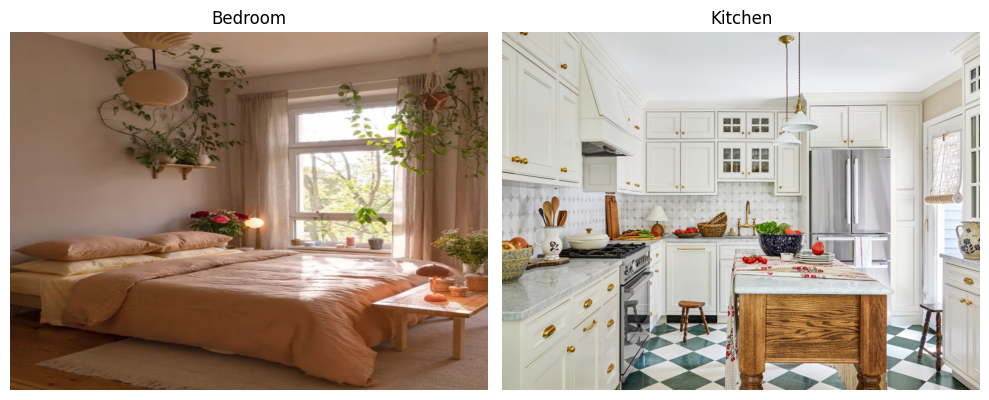

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 5)) # Adjust figsize as needed
axs[0].imshow(image1)
axs[0].axis('off')
axs[0].set_title('Bedroom')

axs[1].imshow(image2)
axs[1].axis('off')
axs[1].set_title('Kitchen')

plt.tight_layout()
plt.show()


In [ ]:
Prompt = 'Provide the answer in JSON formt for both the images. The first field of your output is the image number and the second field is the "room-name" that best describes the image?'
images = [image1,image2]
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': images[0]},
            {'type': 'image', 'image': images[1]},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[images], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

output = model.generate(
    **inputs,
    generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
    return_dict_in_generate=True,
    use_model_defaults=True,
)

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)
print(response)

 Based on the description provided, here's the answer in the requested JSON format:

{
  "image_number": 1,
  "room-name": "Bedroom"
}

{
  "image_number": 2,
  "room-name": "Kitchen"
}


In [ ]:
Prompt_prefix = 'Look at the input images and remeber the image number along with the "room-name" that best describes the image.'
Prompt_suffix = "Which image should I reach out to complete my task? Provide the answer in JSON format with fist field being the image number and second field being the explaination for your choice."

Prompt_user = "I want some orange juice."
Prompt = Prompt_prefix + Prompt_user + Prompt_suffix
images = [image1,image2]
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': images[0]},
            {'type': 'image', 'image': images[1]},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[images], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

output = model.generate(
    **inputs,
    generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
    return_dict_in_generate=True,
    use_model_defaults=True,
)

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)
print(response)

 Based on the description provided, the image that best matches the request for an orange juice is:

{
  "image_number": "1",
  "room_name": "Kitchen"
}

The kitchen is the most appropriate room for preparing orange juice, as it is the space where one would typically find a refrigerator, sink, and countertop for mixing and serving the beverage. The other options, such as a bedroom or living room, are not suitable for making orange juice.


In [ ]:
Prompt = 'Which image shows a window and which one shows a door?'
images = [image1,image2]
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': images[0]},
            {'type': 'image', 'image': images[1]},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[images], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

output = model.generate(
    **inputs,
    generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
    return_dict_in_generate=True,
    use_model_defaults=True,
)

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)
print(response)

 The image that shows a window is the bedroom. The window is located in the bedroom and is covered with curtains. The image that shows a door is the kitchen. The door is located in the kitchen and is covered with a curtain.


# Robot Specific Context

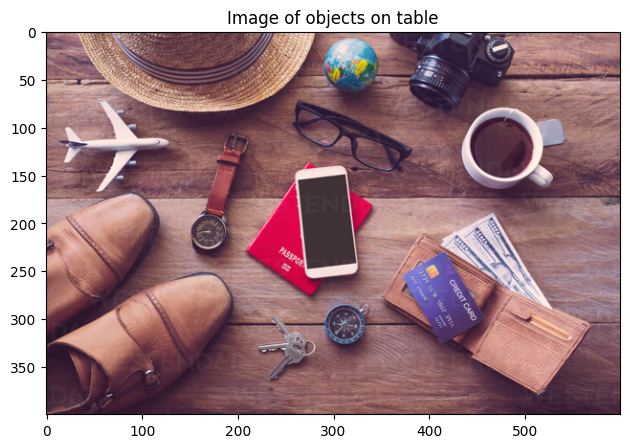

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/Table.jpg")
img = img.resize((600,400), Image.BICUBIC)

plt.imshow(img)
plt.title("Image of objects on table")
plt.tight_layout()
plt.show()

In [ ]:
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': "Can you find a compass in the image? Describe its physical appearance"},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[img], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

with torch.no_grad():
  output = model.generate(
      **inputs,
      generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
      return_dict_in_generate=True,
      use_model_defaults=True,
      use_cache=False
  )

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)
print(response)

 Yes, there is a compass in the image. It is located towards the bottom center of the image. The compass appears to be a small, round object with a needle pointing in a specific direction. It is likely made of metal and has a dark color, possibly black or dark blue, to stand out against the lighter background. The compass is placed on a wooden surface, and it seems to be a standard travel compass used for navigation.


In [ ]:
Prompt_user = "I want to open my room's lock. "

Prompt_preset1 = "What item should my robot pickup? "
Prompt_preset2 = "Provide a JSON output, stating the shape, colour, approximate location of the item in the image, the name of the item being picked up, and the reason for your choice. "
Prompt_preset3 = "Example output- {'Shape': 'Circle', 'Colour': 'Blue', 'Location': 'Middle-Left', 'Name': 'Compass', 'Reason': 'Wanted to navigate'} "

Prompt = Prompt_user + Prompt_preset1 + Prompt_preset2 + Prompt_preset3
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[img], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

output = model.generate(
    **inputs,
    generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
    return_dict_in_generate=True,
    use_model_defaults=True,
    #use_cache=False
)

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)
print(response)

 {
  "Shape": "Key",
  "Colour": "Silver",
  "Location": "Middle-Right",
  "Name": "Keys",
  "Reason": "Needed to open the room's lock"
}


In [ ]:
Prompt_user = "I want to pay my groccery bills. "

Prompt_preset1 = "Which item from the image should I choose? "
Prompt_preset2 = "Provide a JSON output, stating the shape, colour, approximate location of the item in the image, the name of the item choosen, and the reason for your choice. "
Prompt_preset3 = "Example output- {'Shape': 'Circle', 'Colour': 'Blue', 'Location': 'Middle-Left', 'Name': 'Compass', 'Reason': 'Wanted to navigate'} "

Prompt = Prompt_user + Prompt_preset1 + Prompt_preset2 + Prompt_preset3
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[img], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

with torch.no_grad():
  output = model.generate(
      **inputs,
      generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
      return_dict_in_generate=True,
      use_model_defaults=True,
      #use_cache=False
  )

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)
print(response)

 {
  "Shape": "Square",
  "Colour": "Brown",
  "Location": "Bottom-Right",
  "Name": "Wallet",
  "Reason": "Needed to carry money and credit card"
}


In [ ]:
Prompt_user = "I want the compass for navigation. "

Prompt_preset1 = "Which item from the image should I choose? "
Prompt_preset2 = "Provide a JSON output, stating the shape, colour, approximate location of the item in the image, the name of the item choosen, and the reason for your choice. "
Prompt_preset3 = "Example output- {'Shape': 'Pentagon', 'Colour': 'Pink', 'Location': 'Centre-Forward', 'Name': 'Apple', 'Reason': 'Wanted an apple'} "

Prompt = Prompt_user + Prompt_preset1 + Prompt_preset2 + Prompt_preset3
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[img], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

with torch.no_grad():
  output = model.generate(
      **inputs,
      generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
      return_dict_in_generate=True,
      use_model_defaults=True,
      #use_cache=False
  )

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)
print(response)

 {
  "Shape": "Circle",
  "Colour": "Blue",
  "Location": "Top-Right",
  "Name": "Compass",
  "Reason": "Needed a compass for navigation"
}


# Bounding Box

 {
  "Name": "Keys",
  "Confidence": "0.85",
  "xywh": "[0.35, 0.75, 0.15, 0.15]",
  "Reason": "Keys are typically used to unlock doors and are a common travel item."
}


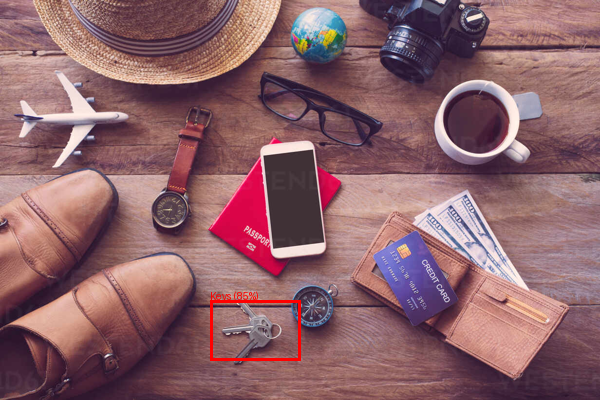

In [ ]:
from PIL import Image, ImageDraw
from IPython.display import display
import ast
import json
import re

img = Image.open("/content/Table.jpg")
img = img.resize((600,400), Image.BICUBIC)

Prompt_user = "I want to open my room's lock. "

Prompt_preset1 = "Which is the one most relevant item from the image, that can be used? "
Prompt_preset2 = "Return a JSON style output for that item, with the following fields: name of the item being picked up, confidence, and xywh (bounding box coordinates, normalized to 0-1) of the item, and the reason for your choice. "
Prompt_preset3 = "Random example of expected output- {'Name': 'Compass', 'Confidence': '0.92', 'xywh': '[0.15, 0.30, 0.20, 0.25]',  'Reason': 'Wanted to navigate'} "

Prompt = Prompt_user + Prompt_preset1 + Prompt_preset2 + Prompt_preset3
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[img], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

output = model.generate(
    **inputs,
    generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
    return_dict_in_generate=True,
    use_model_defaults=True
)

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)

print(response)
out_str = ""
match = re.search(r"\{.*?\}", response, re.DOTALL)
if match:
    out_str = match.group(0)

obj = json.loads(out_str)
draw = ImageDraw.Draw(img)

img_width, img_height = img.size

xywh = ast.literal_eval(obj["xywh"])
x_norm, y_norm, w_norm, h_norm = xywh
x = int(x_norm * img_width)
y = int(y_norm * img_height)
w = int(w_norm * img_width)
h = int(h_norm * img_height)

draw.rectangle([x, y, x + w, y + h], outline="red", width=3)
confidence = float(obj["Confidence"])
label = f"{obj['Name']} ({confidence*100:.0f}%)"
draw.text((x, y - 10), label, fill="red")

display(img)

 Based on the image, the most relevant item for an international trip would be the passport. Here's the JSON-style output for that item:

```json
{
  "Name": "Passport",
  "Confidence": "0.95",
  "xywh": "[0.35, 0.50, 0.20, 0.15]",
  "Reason": "A passport is essential for international travel as it serves as proof of identity and citizenship, allowing you to enter and exit countries legally."
}
```

The passport is the most relevant item because it is directly related to international travel and is a critical document for crossing borders.


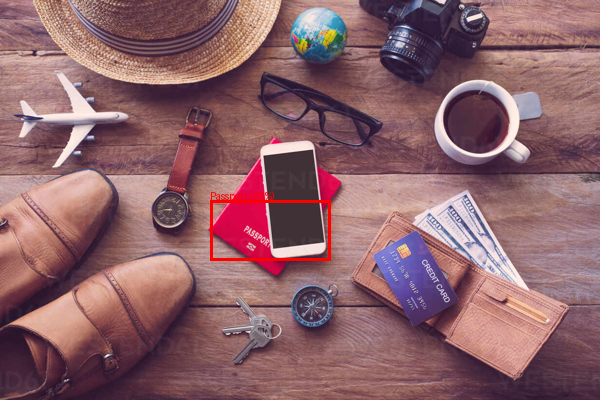

In [ ]:
from PIL import Image, ImageDraw
from IPython.display import display
import ast
import json
import re

img = Image.open("/content/Table.jpg")
img = img.resize((600,400), Image.BICUBIC)

Prompt_user = "I need to go on an international trip. "

Prompt_preset1 = "Which is the one most relevant item from the image, that can be used? "
Prompt_preset2 = "Return a JSON style output for that item, with the following fields: name of the item being picked up, confidence, and xywh (bounding box coordinates, normalized to 0-1) of the item, and the reason for your choice. "
Prompt_preset3 = "Random example of expected output- {'Name': 'Compass', 'Confidence': '0.92', 'xywh': '[0.15, 0.30, 0.20, 0.25]',  'Reason': 'Wanted to navigate'} "

Prompt = Prompt_user + Prompt_preset1 + Prompt_preset2 + Prompt_preset3
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[img], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

output = model.generate(
    **inputs,
    generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
    return_dict_in_generate=True,
    use_model_defaults=True
)

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)

print(response)
out_str = ""
match = re.search(r"\{.*?\}", response, re.DOTALL)
if match:
    out_str = match.group(0)

obj = json.loads(out_str)
draw = ImageDraw.Draw(img)

img_width, img_height = img.size

xywh = ast.literal_eval(obj["xywh"])
x_norm, y_norm, w_norm, h_norm = xywh
x = int(x_norm * img_width)
y = int(y_norm * img_height)
w = int(w_norm * img_width)
h = int(h_norm * img_height)

draw.rectangle([x, y, x + w, y + h], outline="red", width=3)
confidence = float(obj["Confidence"])
label = f"{obj['Name']} ({confidence*100:.0f}%)"
draw.text((x, y - 10), label, fill="red")

display(img)

 {
  "Name": "Watch",
  "Confidence": "0.85",
  "xywh": "[0.25, 0.45, 0.15, 0.20]",
  "Reason": "The watch is a common timekeeping device and is easily identifiable among the items."
}


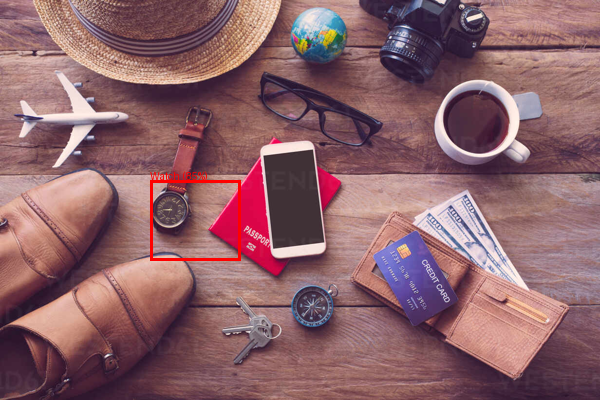

In [ ]:
from PIL import Image, ImageDraw
from IPython.display import display
import ast
import json
import re

img = Image.open("/content/Table.jpg")
img = img.resize((600,400), Image.BICUBIC)

Prompt_user = "I need to know the current time. "

Prompt_preset1 = "Which is the one most relevant item from the image, that can be used? "
Prompt_preset2 = "Return a JSON style output for that item, with the following fields: name of the item being picked up, confidence, and xywh (bounding box coordinates, normalized to 0-1) of the item, and the reason for your choice. "
Prompt_preset3 = "Random example of expected output- {'Name': 'Compass', 'Confidence': '0.92', 'xywh': '[0.15, 0.30, 0.20, 0.25]',  'Reason': 'Wanted to navigate'} "

Prompt = Prompt_user + Prompt_preset1 + Prompt_preset2 + Prompt_preset3
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': Prompt},
        ],
    }
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text], images=[img], padding='longest', return_tensors='pt')
inputs = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

output = model.generate(
    **inputs,
    generation_config=GenerationConfig(max_new_tokens=512, do_sample=False),
    return_dict_in_generate=True,
    use_model_defaults=True
)

response = processor.tokenizer.decode(
    output.sequences[0][inputs['input_ids'].shape[-1]:],
    skip_special_tokens=True
)

print(response)
out_str = ""
match = re.search(r"\{.*?\}", response, re.DOTALL)
if match:
    out_str = match.group(0)

obj = json.loads(out_str)
draw = ImageDraw.Draw(img)

img_width, img_height = img.size

xywh = ast.literal_eval(obj["xywh"])
x_norm, y_norm, w_norm, h_norm = xywh
x = int(x_norm * img_width)
y = int(y_norm * img_height)
w = int(w_norm * img_width)
h = int(h_norm * img_height)

draw.rectangle([x, y, x + w, y + h], outline="red", width=3)
confidence = float(obj["Confidence"])
label = f"{obj['Name']} ({confidence*100:.0f}%)"
draw.text((x, y - 10), label, fill="red")

display(img)

# Grounding DINO

In [1]:
!pip install -q transformers torch pillow requests accelerate

In [2]:
import requests
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

In [3]:
# Model ID
model_id = "IDEA-Research/grounding-dino-tiny"

# Device setup (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# Load processor and model
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id)
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

GroundingDinoForObjectDetection(
  (model): GroundingDinoModel(
    (backbone): GroundingDinoConvModel(
      (conv_encoder): GroundingDinoConvEncoder(
        (model): SwinBackbone(
          (embeddings): SwinEmbeddings(
            (patch_embeddings): SwinPatchEmbeddings(
              (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
            )
            (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (encoder): SwinEncoder(
            (layers): ModuleList(
              (0): SwinStage(
                (blocks): ModuleList(
                  (0): SwinLayer(
                    (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
                    (attention): SwinAttention(
                      (self): SwinSelfAttention(
                        (query): Linear(in_features=96, out_features=96, bias=True)
                        (key): Linear(in_features=9

In [25]:
from IPython.display import display
# Load image
image = Image.open("/content/Table.jpg").convert("RGB")

# Labels to detect
text_labels = [["wallet", "paper money", "keys", "credit card"]]

In [26]:
# Prepare inputs
inputs = processor(
    images=image,
    text=text_labels,
    return_tensors="pt"
)
inputs = {k: v.to(device) for k, v in inputs.items()}

In [27]:
# Run inference
with torch.no_grad():
    outputs = model(**inputs)

# Post-process results
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs["input_ids"],
    threshold=0.4,
    text_threshold=0.3,
    target_sizes=[image.size[::-1]]  # (height, width)
)

In [28]:
# Print detections
result = results[0]
for box, score, label in zip(result["boxes"], result["scores"], result["labels"]):
    box = [round(x, 2) for x in box.tolist()]
    print(
        f"Detected '{label}' "
        f"with confidence {round(score.item(), 3)} "
        f"at location {box}"
    )

Detected 'keys' with confidence 0.56 at location [454.26, 607.53, 579.15, 749.52]
Detected 'keys' with confidence 0.494 at location [28.24, 141.96, 264.47, 345.65]
Detected 'credit card' with confidence 0.499 at location [764.4, 471.64, 941.97, 671.0]
Detected 'paper money' with confidence 0.462 at location [845.35, 386.82, 1088.14, 597.9]
Detected 'paper money' with confidence 0.41 at location [426.6, 279.84, 700.09, 568.58]
Detected 'wallet' with confidence 0.544 at location [719.42, 427.64, 1170.62, 781.8]


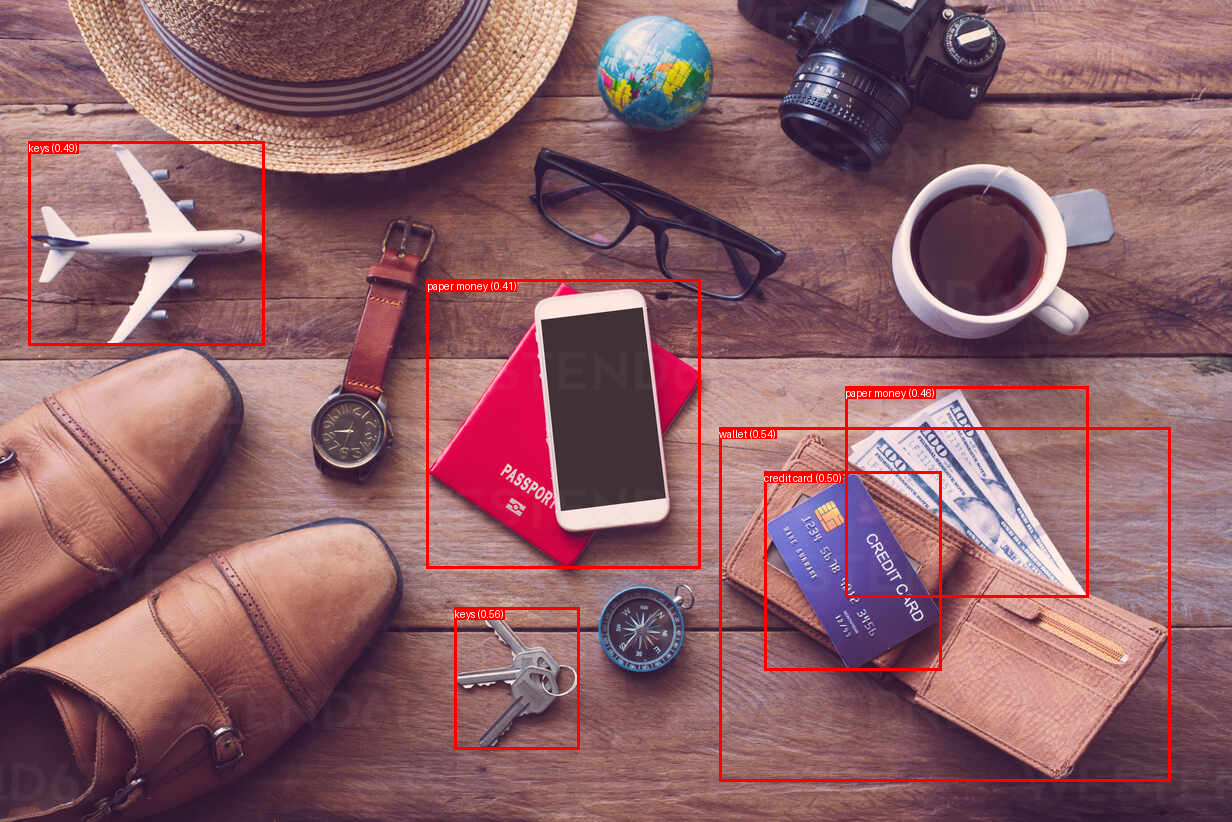

In [29]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
import torch

# Copy the image to draw on
image_with_boxes = image.copy()
draw = ImageDraw.Draw(image_with_boxes)

# Optional: load a font
try:
    font = ImageFont.truetype("DejaVuSans.ttf", 16)
except:
    font = ImageFont.load_default()

# Draw each detection
for box, score, label in zip(result['boxes'], result['scores'], result['text_labels']):
    box = box.tolist()  # convert tensor to list
    label_text = f"{label} ({score.item():.2f})"

    # Draw rectangle
    draw.rectangle(box, outline="red", width=3)

    # Draw label background
    text_bbox = draw.textbbox((box[0], box[1]), label_text, font=font)
    draw.rectangle(text_bbox, fill="red")

    # Draw text
    draw.text((box[0], box[1]), label_text, fill="white", font=font)

# Display the image with bounding boxes
display(image_with_boxes)
